In [1]:
import numpy as np
import pandas as pd

# -----------------------------
# Monte Carlo valuation model
# for seladelpar / CymaBay
# -----------------------------

np.random.seed(42)

# Number of simulations
N_SIM = 10000

# -----------------------------
# Assumptions
# -----------------------------
# Peak sales distribution (in USD millions)
# triangular(min, mode, max)
PEAK_SALES_MIN = 650
PEAK_SALES_MODE = 850
PEAK_SALES_MAX = 1100

# Probability of approval at acquisition date
APPROVAL_PROB = 0.85

# Time to peak sales (years)
TIME_TO_PEAK_OPTIONS = [4, 5, 6]

# Exclusivity duration after launch (years)
EXCLUSIVITY_OPTIONS = [10, 11, 12]

# Operating margin distribution
MARGIN_MEAN = 0.65
MARGIN_STD = 0.05

# Discount rate distribution
DISCOUNT_MEAN = 0.11
DISCOUNT_STD = 0.015

# Launch year cash flow starts after acquisition
LAUNCH_DELAY = 1  # years from valuation date to first commercial year

# Revenue ramp shape
# Fraction of peak sales reached each year up to peak
# Example: if time_to_peak = 5, revenues ramp linearly to peak in 5 years
def build_revenue_path(peak_sales, time_to_peak, exclusivity_years):
    revenues = []
    for year in range(1, exclusivity_years + 1):
        if year <= time_to_peak:
            revenue = peak_sales * (year / time_to_peak)
        else:
            revenue = peak_sales
        revenues.append(revenue)
    return np.array(revenues)

# -----------------------------
# Simulation
# -----------------------------
results = []

for _ in range(N_SIM):
    # Draw uncertain inputs
    peak_sales = np.random.triangular(
        PEAK_SALES_MIN, PEAK_SALES_MODE, PEAK_SALES_MAX
    )  # USD millions

    approved = np.random.binomial(1, APPROVAL_PROB)

    time_to_peak = np.random.choice(TIME_TO_PEAK_OPTIONS)
    exclusivity_years = np.random.choice(EXCLUSIVITY_OPTIONS)

    operating_margin = np.random.normal(MARGIN_MEAN, MARGIN_STD)
    operating_margin = np.clip(operating_margin, 0.45, 0.80)

    discount_rate = np.random.normal(DISCOUNT_MEAN, DISCOUNT_STD)
    discount_rate = np.clip(discount_rate, 0.07, 0.16)

    # If not approved, value is zero
    if approved == 0:
        npv = 0.0
    else:
        revenues = build_revenue_path(peak_sales, time_to_peak, exclusivity_years)
        operating_profits = revenues * operating_margin

        discounted_cash_flows = []
        for t, cash_flow in enumerate(operating_profits, start=LAUNCH_DELAY):
            pv = cash_flow / ((1 + discount_rate) ** t)
            discounted_cash_flows.append(pv)

        npv = np.sum(discounted_cash_flows)  # USD millions

    results.append({
        "peak_sales_musd": peak_sales,
        "approved": approved,
        "time_to_peak": time_to_peak,
        "exclusivity_years": exclusivity_years,
        "operating_margin": operating_margin,
        "discount_rate": discount_rate,
        "npv_musd": npv
    })

df = pd.DataFrame(results)

# -----------------------------
# Summary statistics
# -----------------------------
summary = {
    "Mean NPV ($B)": df["npv_musd"].mean() / 1000,
    "Median NPV ($B)": df["npv_musd"].median() / 1000,
    "5th percentile ($B)": df["npv_musd"].quantile(0.05) / 1000,
    "25th percentile ($B)": df["npv_musd"].quantile(0.25) / 1000,
    "75th percentile ($B)": df["npv_musd"].quantile(0.75) / 1000,
    "95th percentile ($B)": df["npv_musd"].quantile(0.95) / 1000,
    "P(NPV > $4.3B)": (df["npv_musd"] > 4300).mean()
}

summary_df = pd.DataFrame(summary, index=[0])

print("\nMonte Carlo valuation summary:")

summary = {
    "Mean NPV ($B)": df["npv_musd"].mean() / 1000,
    "Median NPV ($B)": df["npv_musd"].median() / 1000,
    "5th percentile ($B)": df["npv_musd"].quantile(0.05) / 1000,
    "25th percentile ($B)": df["npv_musd"].quantile(0.25) / 1000,
    "75th percentile ($B)": df["npv_musd"].quantile(0.75) / 1000,
    "95th percentile ($B)": df["npv_musd"].quantile(0.95) / 1000,
    "Probability NPV > $4.3B": (df["npv_musd"] > 4300).mean()
}

for k, v in summary.items():
    print(f"{k:25s}: {v:.3f}")


Monte Carlo valuation summary:
Mean NPV ($B)            : 2.211
Median NPV ($B)          : 2.458
5th percentile ($B)      : 0.000
25th percentile ($B)     : 2.068
75th percentile ($B)     : 2.813
95th percentile ($B)     : 3.343
Probability NPV > $4.3B  : 0.000


In [2]:
print("\nMonte Carlo valuation summary:")

summary = {
    "Mean NPV ($B)": df["npv_musd"].mean() / 1000,
    "Median NPV ($B)": df["npv_musd"].median() / 1000,
    "5th percentile ($B)": df["npv_musd"].quantile(0.05) / 1000,
    "25th percentile ($B)": df["npv_musd"].quantile(0.25) / 1000,
    "75th percentile ($B)": df["npv_musd"].quantile(0.75) / 1000,
    "95th percentile ($B)": df["npv_musd"].quantile(0.95) / 1000,
    "Probability NPV > $4.3B": (df["npv_musd"] > 4300).mean()
}

for k, v in summary.items():
    print(f"{k:25s}: {v:.3f}")


Monte Carlo valuation summary:
Mean NPV ($B)            : 2.211
Median NPV ($B)          : 2.458
5th percentile ($B)      : 0.000
25th percentile ($B)     : 2.068
75th percentile ($B)     : 2.813
95th percentile ($B)     : 3.343
Probability NPV > $4.3B  : 0.000


In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

# -----------------------------
# SETTINGS
# -----------------------------
N_SIM = 10000
ACQUISITION_PRICE_B = 4.3  # $ billions

# -----------------------------
# HELPER FUNCTIONS
# -----------------------------
def triangular_int(left, mode, right, size=None):
    return np.rint(np.random.triangular(left, mode, right, size)).astype(int)

def sample_clipped_normal(mean, std, low, high, size=None):
    x = np.random.normal(mean, std, size)
    return np.clip(x, low, high)

def build_revenue_curve(peak_revenue, ramp_years, exclusivity_years, decline_years=3):
    """
    Builds a revenue path:
    - Smoother adoption ramp to peak
    - Plateau at peak until exclusivity ends
    - Post-exclusivity erosion tail
    Returns annual revenues in $ millions.
    """
    # Typical pharma launch ramp
    ramp_templates = {
        4: [0.15, 0.40, 0.75, 1.00],
        5: [0.10, 0.25, 0.50, 0.75, 1.00],
        6: [0.08, 0.18, 0.35, 0.55, 0.78, 1.00],
    }
    ramp = ramp_templates[ramp_years]
    revenues = [peak_revenue * x for x in ramp]

    plateau_years = max(exclusivity_years - ramp_years, 0)
    revenues.extend([peak_revenue] * plateau_years)

    # Simple post-exclusivity decline tail
    erosion = [0.40, 0.20, 0.10][:decline_years]
    revenues.extend([peak_revenue * x for x in erosion])

    return np.array(revenues)

def discount_cashflows(cashflows, discount_rate, start_year=1):
    discounted = []
    for t, cf in enumerate(cashflows, start=start_year):
        discounted.append(cf / ((1 + discount_rate) ** t))
    return np.array(discounted)

# -----------------------------
# ASSUMPTIONS
# -----------------------------
# Addressable treated population in PBC (patients eligible / reachable commercially)
ADDRESSABLE_PATIENTS_MIN = 35000
ADDRESSABLE_PATIENTS_MODE = 45000
ADDRESSABLE_PATIENTS_MAX = 60000

# Peak market penetration
PENETRATION_MIN = 0.20
PENETRATION_MODE = 0.30
PENETRATION_MAX = 0.45

# Net annual price per patient in USD
PRICE_MIN = 70000
PRICE_MODE = 85000
PRICE_MAX = 100000

# Probability of approval at acquisition date
APPROVAL_PROB_MIN = 0.80
APPROVAL_PROB_MODE = 0.87
APPROVAL_PROB_MAX = 0.93

# Time to peak sales
RAMP_YEAR_OPTIONS = [4, 5, 6]

# Effective exclusivity duration (years of branded economics before steep erosion)
EXCLUSIVITY_MIN = 10
EXCLUSIVITY_MODE = 12
EXCLUSIVITY_MAX = 14

# Operating margin
MARGIN_MEAN = 0.62
MARGIN_STD = 0.06
MARGIN_LOW = 0.45
MARGIN_HIGH = 0.78

# Discount rate
DISCOUNT_MEAN = 0.105
DISCOUNT_STD = 0.015
DISCOUNT_LOW = 0.08
DISCOUNT_HIGH = 0.15

# First commercial cash flow arrives after acquisition
LAUNCH_DELAY = 1

# Optional strategic premium / synergy in $M
# Set to zero if you want pure standalone asset value
SYNERGY_MIN = 0
SYNERGY_MODE = 250
SYNERGY_MAX = 750

# -----------------------------
# SIMULATION
# -----------------------------
rows = []

for _ in range(N_SIM):
    addressable_patients = triangular_int(
        ADDRESSABLE_PATIENTS_MIN,
        ADDRESSABLE_PATIENTS_MODE,
        ADDRESSABLE_PATIENTS_MAX
    )

    peak_penetration = np.random.triangular(
        PENETRATION_MIN, PENETRATION_MODE, PENETRATION_MAX
    )

    annual_price = np.random.triangular(
        PRICE_MIN, PRICE_MODE, PRICE_MAX
    )

    approval_prob = np.random.triangular(
        APPROVAL_PROB_MIN, APPROVAL_PROB_MODE, APPROVAL_PROB_MAX
    )

    ramp_years = np.random.choice(RAMP_YEAR_OPTIONS)

    exclusivity_years = int(np.rint(np.random.triangular(
        EXCLUSIVITY_MIN, EXCLUSIVITY_MODE, EXCLUSIVITY_MAX
    )))

    operating_margin = sample_clipped_normal(
        MARGIN_MEAN, MARGIN_STD, MARGIN_LOW, MARGIN_HIGH
    )

    discount_rate = sample_clipped_normal(
        DISCOUNT_MEAN, DISCOUNT_STD, DISCOUNT_LOW, DISCOUNT_HIGH
    )

    synergy_value = np.random.triangular(
        SYNERGY_MIN, SYNERGY_MODE, SYNERGY_MAX
    )  # $M PV-style add-on

    # Peak revenue in $M
    peak_revenue = (addressable_patients * peak_penetration * annual_price) / 1e6

    # Revenue path and operating profit path
    revenues = build_revenue_curve(
        peak_revenue=peak_revenue,
        ramp_years=ramp_years,
        exclusivity_years=exclusivity_years,
        decline_years=3
    )

    operating_profits = revenues * operating_margin

    discounted_operating_profits = discount_cashflows(
        operating_profits,
        discount_rate=discount_rate,
        start_year=LAUNCH_DELAY
    )

    npv_if_approved = discounted_operating_profits.sum() + synergy_value

    # Risk-adjusted NPV
    rnpv = approval_prob * npv_if_approved

    rows.append({
        "addressable_patients": addressable_patients,
        "peak_penetration": peak_penetration,
        "annual_price_usd": annual_price,
        "approval_prob": approval_prob,
        "ramp_years": ramp_years,
        "exclusivity_years": exclusivity_years,
        "operating_margin": operating_margin,
        "discount_rate": discount_rate,
        "peak_revenue_musd": peak_revenue,
        "npv_if_approved_musd": npv_if_approved,
        "rnpv_musd": rnpv,
        "synergy_musd": synergy_value,
    })

df = pd.DataFrame(rows)

# -----------------------------
# SUMMARY
# -----------------------------
summary = {
    "Mean rNPV ($B)": df["rnpv_musd"].mean() / 1000,
    "Median rNPV ($B)": df["rnpv_musd"].median() / 1000,
    "5th percentile ($B)": df["rnpv_musd"].quantile(0.05) / 1000,
    "25th percentile ($B)": df["rnpv_musd"].quantile(0.25) / 1000,
    "75th percentile ($B)": df["rnpv_musd"].quantile(0.75) / 1000,
    "95th percentile ($B)": df["rnpv_musd"].quantile(0.95) / 1000,
    "Mean peak sales ($B)": df["peak_revenue_musd"].mean() / 1000,
    "P(rNPV > $4.3B)": (df["rnpv_musd"] > ACQUISITION_PRICE_B * 1000).mean(),
}

print("\nMonte Carlo valuation summary:")
for k, v in summary.items():
    print(f"{k:25s}: {v:.3f}")

# Optional driver diagnostics
print("\nAverage simulated assumptions:")
print(f"{'Addressable patients':25s}: {df['addressable_patients'].mean():,.0f}")
print(f"{'Peak penetration':25s}: {df['peak_penetration'].mean():.3f}")
print(f"{'Annual price ($)':25s}: {df['annual_price_usd'].mean():,.0f}")
print(f"{'Approval probability':25s}: {df['approval_prob'].mean():.3f}")
print(f"{'Operating margin':25s}: {df['operating_margin'].mean():.3f}")
print(f"{'Discount rate':25s}: {df['discount_rate'].mean():.3f}")
print(f"{'Exclusivity years':25s}: {df['exclusivity_years'].mean():.2f}")
print(f"{'Synergy value ($M)':25s}: {df['synergy_musd'].mean():.1f}")

# Save outputs
df.to_csv("seladelpar_monte_carlo_detailed.csv", index=False)
pd.DataFrame([summary]).to_csv("seladelpar_monte_carlo_summary.csv", index=False)

print("\nFiles saved:")
print("- seladelpar_monte_carlo_detailed.csv")
print("- seladelpar_monte_carlo_summary.csv")


Monte Carlo valuation summary:
Mean rNPV ($B)           : 3.607
Median rNPV ($B)         : 3.510
5th percentile ($B)      : 2.324
25th percentile ($B)     : 2.938
75th percentile ($B)     : 4.148
95th percentile ($B)     : 5.293
Mean peak sales ($B)     : 1.258
P(rNPV > $4.3B)          : 0.204

Average simulated assumptions:
Addressable patients     : 46,706
Peak penetration         : 0.317
Annual price ($)         : 85,011
Approval probability     : 0.867
Operating margin         : 0.621
Discount rate            : 0.105
Exclusivity years        : 12.00
Synergy value ($M)       : 332.2

Files saved:
- seladelpar_monte_carlo_detailed.csv
- seladelpar_monte_carlo_summary.csv


In [4]:
import os
os.makedirs("figures", exist_ok=True)

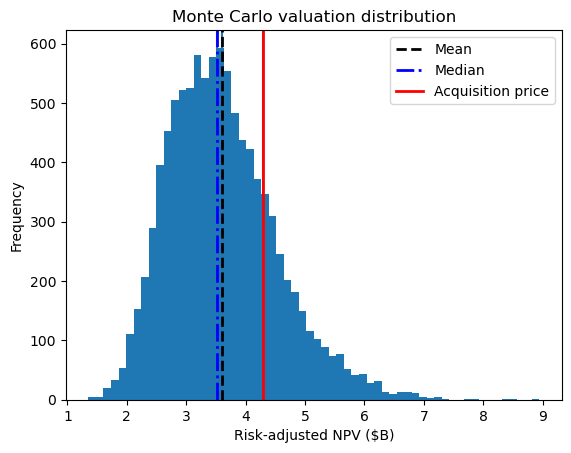

In [5]:
import matplotlib.pyplot as plt

npv_b = df["rnpv_musd"] / 1000

plt.figure()
plt.hist(npv_b, bins=60)

plt.axvline(4.3)
plt.axvline(npv_b.mean())
plt.axvline(npv_b.median())

plt.xlabel("Risk-adjusted NPV ($B)")
plt.ylabel("Frequency")
plt.title("Monte Carlo valuation distribution")
plt.savefig("figures/npv_distribution.png")

plt.axvline(npv_b.mean(), color="black", linestyle="--", linewidth=2, label="Mean")
plt.axvline(npv_b.median(), color="blue", linestyle="-.", linewidth=2, label="Median")
plt.axvline(4.3, color="red", linewidth=2, label="Acquisition price")

plt.legend()

#Across thousands of possible futures, what values could this drug realistically have?

Text(12, 500, 'Patent cliff')

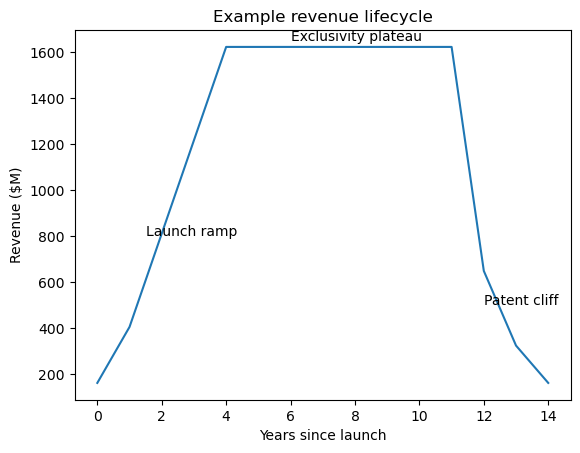

In [6]:
revenues = build_revenue_curve(
    peak_revenue=peak_revenue,
    ramp_years=5,
    exclusivity_years=12
)

plt.figure()
plt.plot(revenues)
plt.xlabel("Years since launch")
plt.ylabel("Revenue ($M)")
plt.title("Example revenue lifecycle")
plt.savefig("figures/revenue_curve.png")

plt.text(1.5, 800, "Launch ramp")
plt.text(6, 1650, "Exclusivity plateau")
plt.text(12, 500, "Patent cliff")

#Revenue ramp → peak monopoly period → generic erosion

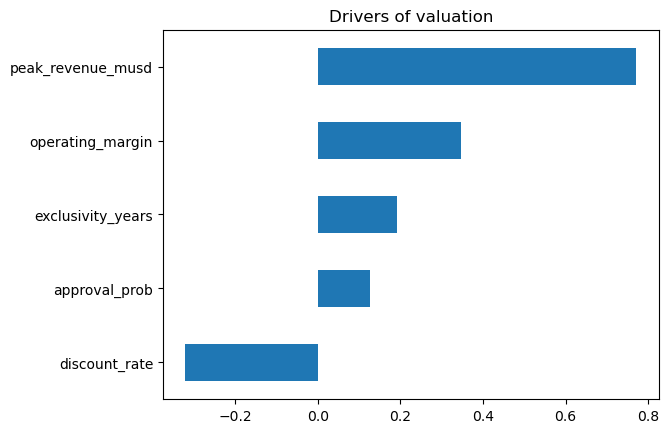

In [7]:
drivers = df[[
    "peak_revenue_musd",
    "approval_prob",
    "operating_margin",
    "discount_rate",
    "exclusivity_years"
]]

corr = drivers.corrwith(df["rnpv_musd"])

corr.sort_values().plot(kind="barh")
plt.title("Drivers of valuation")
plt.savefig("figures/value_drivers.png")

#Positive value → higher input leads to higher valuation
#Negative value → higher input leads to lower valuation
#Magnitude → strength of influence

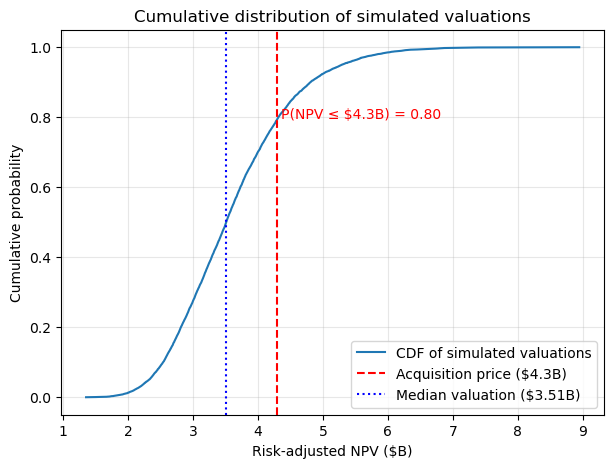

In [8]:
sorted_vals = np.sort(npv_b)
cdf = np.arange(len(sorted_vals)) / len(sorted_vals)

# key statistics
acq_price = 4.3
prob_below = (npv_b <= acq_price).mean()
prob_above = 1 - prob_below
median_val = np.median(npv_b)

plt.figure(figsize=(7,5))

plt.plot(sorted_vals, cdf, label="CDF of simulated valuations")

plt.axvline(acq_price, color="red", linestyle="--", label="Acquisition price ($4.3B)")
plt.axvline(median_val, color="blue", linestyle=":", label=f"Median valuation (${median_val:.2f}B)")

# annotate probability
plt.text(
    acq_price + 0.05,
    prob_below,
    f"P(NPV ≤ $4.3B) = {prob_below:.2f}",
    color="red"
)

plt.xlabel("Risk-adjusted NPV ($B)")
plt.ylabel("Cumulative probability")
plt.title("Cumulative distribution of simulated valuations")

plt.grid(alpha=0.3)
plt.legend()

plt.savefig("figures/cdf_valuation.png", dpi=300)
plt.show()